In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import pandas as pd
import re
import html
import urllib.parse
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, average_precision_score, precision_recall_fscore_support,
    roc_curve, precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==================== config ====================
MAX_LEN      = 90
MAX_VOCAB    = 8000
BATCH        = 64
EPOCHS       = 30
PATIENCE     = 5
LR           = 2e-3
WEIGHT_DECAY = 1e-2
ALPHA_FOCAL  = 0.75
GAMMA_FOCAL  = 2
SMOOTH       = 0.05
HARD_EPOCH   = 1
SEED         = 42
N_SPLITS     = 5  # count folds K-Fold
MODEL_NAME   = 'best_xss_focal_FULL_K_fold.pth'


torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"📌 Using device: {DEVICE}")
print(f"📌 Random seed set to: {SEED}")

📌 Using device: cpu
📌 Random seed set to: 42


In [9]:
def xss_preprocess(text: str) -> str:
    """preprocess text"""
    if pd.isna(text): return ''
    s = str(text).strip()
    s = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]+', ' ', s)
    s = urllib.parse.unquote(s)
    s = html.unescape(s)
    s = re.sub(r'\\u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), s)
    s = s.replace('<', ' < ').replace('>', ' > ')
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return s

def xss_tokenize(text: str):
    """tokenize text"""
    return re.findall(r"\w+|</?\w+|[<>\"'=;:/.\-]|\S", text)[:MAX_LEN]

def encode_with_vocab(tokens_list, w2i):
    """encode tokens to vocab"""
    seqs = []
    for toks in tokens_list:
        seq = [w2i.get(t, 1) for t in toks][:MAX_LEN]  # 1 = <UNK>
        seq += [0] * (MAX_LEN - len(seq))              # 0 = <PAD>
        seqs.append(seq)
    return torch.LongTensor(seqs)

In [10]:
class XSSDetector(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb   = nn.Embedding(vocab_size, 128, padding_idx=0)
        self.drop1 = nn.Dropout(0.2)
        self.convs = nn.ModuleList([nn.Conv1d(128, 128, k, padding=(k//2)) for k in [3,5,7]])
        self.attn  = nn.Sequential(nn.Linear(128*3, 64), nn.Tanh(), nn.Linear(64, 1))
        self.lstm  = nn.LSTM(128*3, 256, batch_first=True, bidirectional=True)
        self.fc    = nn.Sequential(
                        nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4),
                        nn.Linear(128, 2))

    def forward(self, x):
        x = self.emb(x)
        x = self.drop1(x).permute(0,2,1)
        h = torch.cat([F.relu(c(x)) for c in self.convs], dim=1)
        h = h.permute(0,2,1)
        a = self.attn(h)
        a = torch.softmax(a, dim=1)
        h = h * a
        h,_ = self.lstm(h)
        h = torch.max(h, dim=1)[0]
        return self.fc(h)


In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=ALPHA_FOCAL, gamma=GAMMA_FOCAL, smooth=SMOOTH):
        super().__init__()
        self.a, self.g, self.s = alpha, gamma, smooth

    def forward(self, logits, y):
        y_smooth = torch.zeros_like(logits).scatter_(1, y.view(-1,1), 1)
        y_smooth = y_smooth * (1-self.s) + self.s/2.
        log_p = F.log_softmax(logits, dim=1)
        p = torch.exp(log_p)
        loss = -y_smooth * torch.pow(1-p, self.g) * log_p
        alpha_t = torch.tensor([self.a, 1-self.a]).to(logits.device).view(1,2)
        loss = alpha_t * loss
        return loss.sum(dim=1).mean()

In [12]:
df = pd.read_csv('data/XSS_dataset.csv')
texts, labels = df['sentence'].astype(str).values, df['Label'].astype(int).values

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results = []
all_fold_probs = []
all_fold_y_val = []

print(f"\n{'='*60}")
print(f" start K-Fold Cross Validation ({N_SPLITS} folds) ")
print(f"{'='*60}\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, labels), 1):
    print(f"🔸 Fold {fold}/{N_SPLITS} runing...")
    print(f"   Train samples: {len(train_idx)} | Val samples: {len(val_idx)}")

    # تقسیم داده‌ها
    X_train_fold, X_val_fold = texts[train_idx], texts[val_idx]
    y_train_fold, y_val_fold = labels[train_idx], labels[val_idx]

    # پیش‌پردازش
    train_tok = [xss_tokenize(xss_preprocess(t)) for t in X_train_fold]
    val_tok   = [xss_tokenize(xss_preprocess(t)) for t in X_val_fold]

    # ساخت واژه‌نامه مستقل برای این فولد
    counter = Counter(tok for sent in train_tok for tok in sent)
    vocab = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(MAX_VOCAB-2)]
    word2idx = {w: i for i, w in enumerate(vocab)}
    vocab_size = len(vocab)
    print(f"   📊 Vocab size: {vocab_size:,}")

    # اینکد کردن
    X_train = encode_with_vocab(train_tok, word2idx)
    X_val   = encode_with_vocab(val_tok, word2idx)
    y_train = torch.LongTensor(y_train_fold)
    y_val   = torch.LongTensor(y_val_fold)

    # DataLoaders
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_train, y_train),
        batch_size=BATCH, shuffle=True, drop_last=True
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_val, y_val),
        batch_size=BATCH*2
    )

    # مدل، Loss و Optimizer جدید
    model = XSSDetector(vocab_size).to(DEVICE)
    criterion = FocalLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # آموزش + Early Stopping
    best_auc, patience_counter = 0.0, 0
    best_model_state = None
    train_losses, val_aucs = [], []

    for epoch in range(1, EPOCHS + 1):
        # Training
        model.train()
        epoch_loss = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(X_val.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
        auc_score = roc_auc_score(y_val.numpy(), probs)

        train_losses.append(epoch_loss / len(train_loader))
        val_aucs.append(auc_score)

        # Early Stopping
        if auc_score > best_auc:
            best_auc = auc_score
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"   ⏹️  Early stopping at epoch {epoch}")
                break

    # ذخیره نتایج
    fold_results.append({
        'fold': fold,
        'best_auc': best_auc,
        'vocab_size': vocab_size,
        'train_losses': train_losses,
        'val_aucs': val_aucs
    })

    # ذخیره احتمالات برای ROC میانگین
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        fold_probs = torch.softmax(model(X_val.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
        all_fold_probs.append(fold_probs)
        all_fold_y_val.append(y_val.numpy())

    print(f"   ✅ Fold {fold} - Best Val AUC: {best_auc:.4f}\n")
    print(f"{'-'*50}")

# گزارش نهایی
print(f"\n{'='*60}")
print(" 📈 results 5-Fold Cross Validation")
print(f"{'='*60}")

auc_scores = [r['best_auc'] for r in fold_results]
print(f"\nAUC per fold: {[f'{score:.4f}' for score in auc_scores]}")
print(f"Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# ذخیره در CSV
df_results = pd.DataFrame(fold_results)
df_results.to_csv('kfold_results.csv', index=False)
print("\n✅ results saved: 'kfold_results.csv'")


 start K-Fold Cross Validation (5 folds) 

🔸 Fold 1/5 runing...
   Train samples: 10948 | Val samples: 2738
   📊 Vocab size: 7,104
   ⏹️  Early stopping at epoch 9
   ✅ Fold 1 - Best Val AUC: 1.0000

--------------------------------------------------
🔸 Fold 2/5 runing...
   Train samples: 10949 | Val samples: 2737
   📊 Vocab size: 7,212
   ⏹️  Early stopping at epoch 10
   ✅ Fold 2 - Best Val AUC: 1.0000

--------------------------------------------------
🔸 Fold 3/5 runing...
   Train samples: 10949 | Val samples: 2737
   📊 Vocab size: 7,134
   ⏹️  Early stopping at epoch 9
   ✅ Fold 3 - Best Val AUC: 0.9999

--------------------------------------------------
🔸 Fold 4/5 runing...
   Train samples: 10949 | Val samples: 2737
   📊 Vocab size: 7,142
   ⏹️  Early stopping at epoch 23
   ✅ Fold 4 - Best Val AUC: 1.0000

--------------------------------------------------
🔸 Fold 5/5 runing...
   Train samples: 10949 | Val samples: 2737
   📊 Vocab size: 7,160
   ⏹️  Early stopping at epoch 12


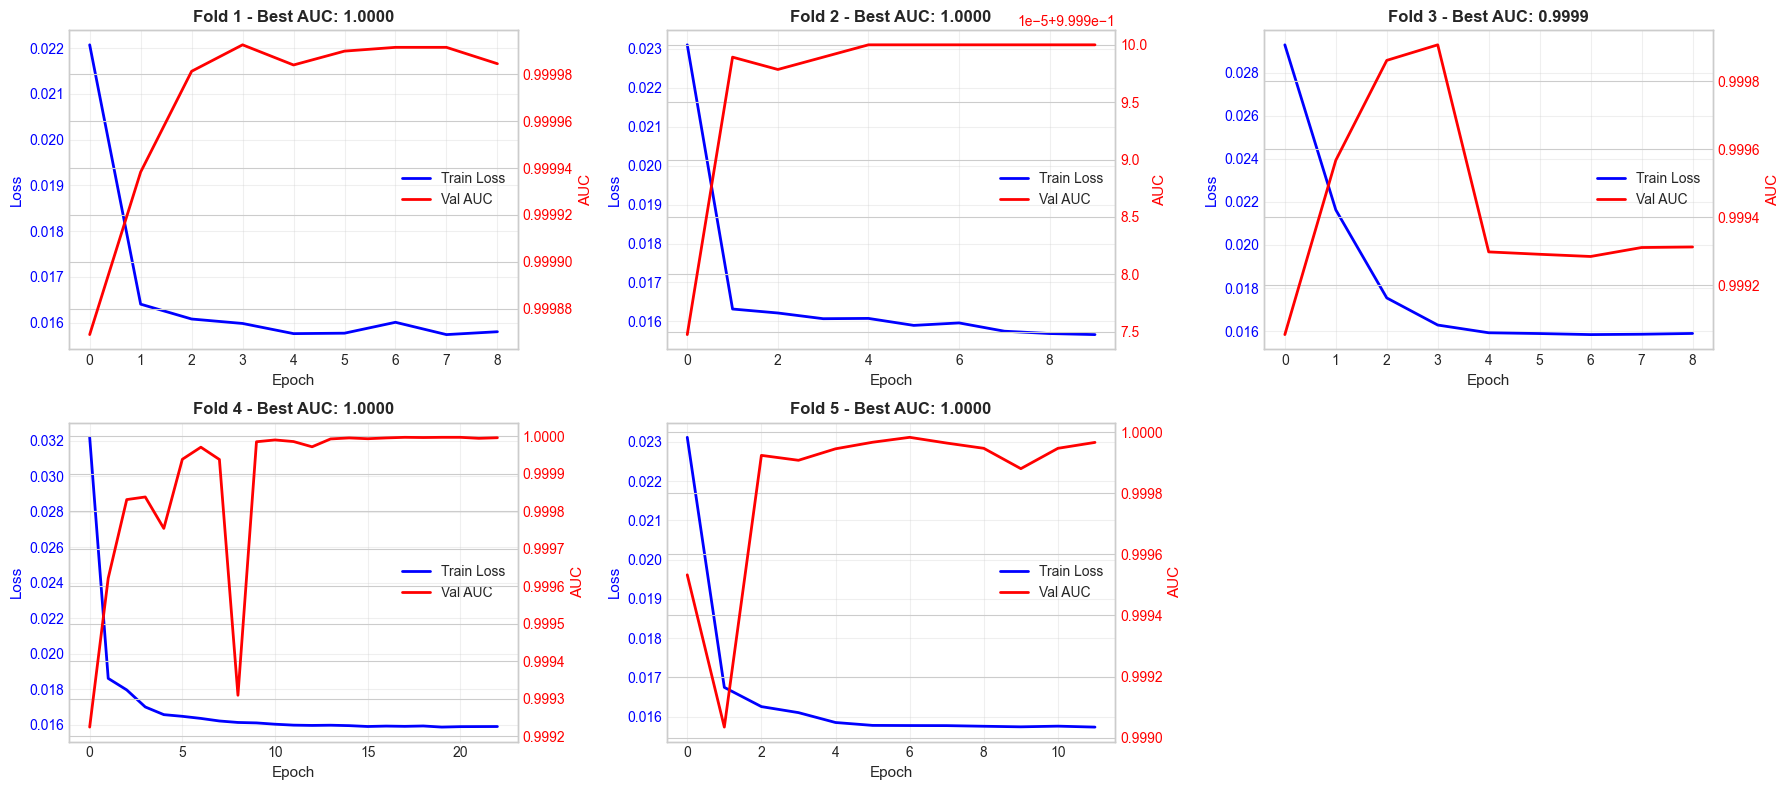

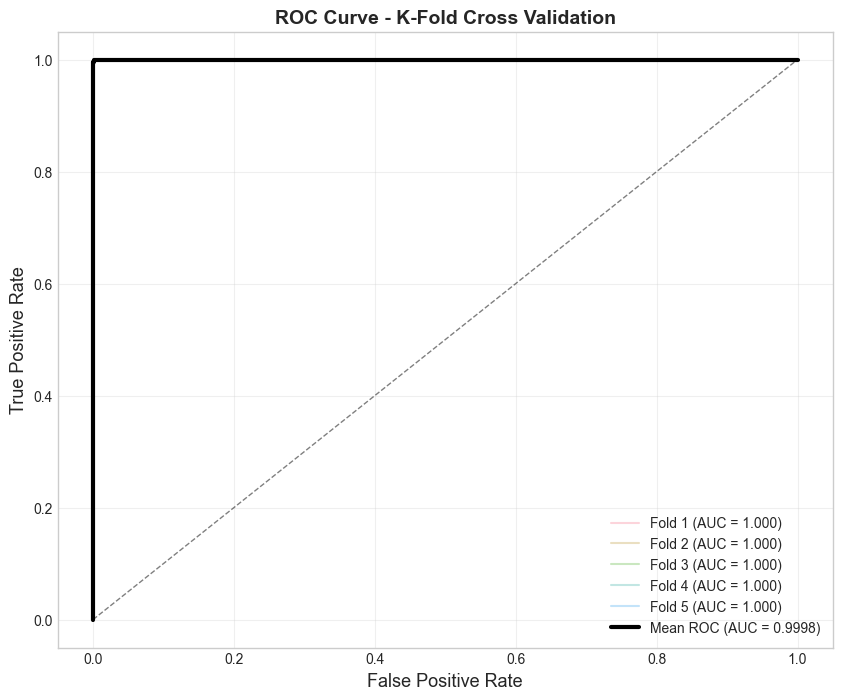

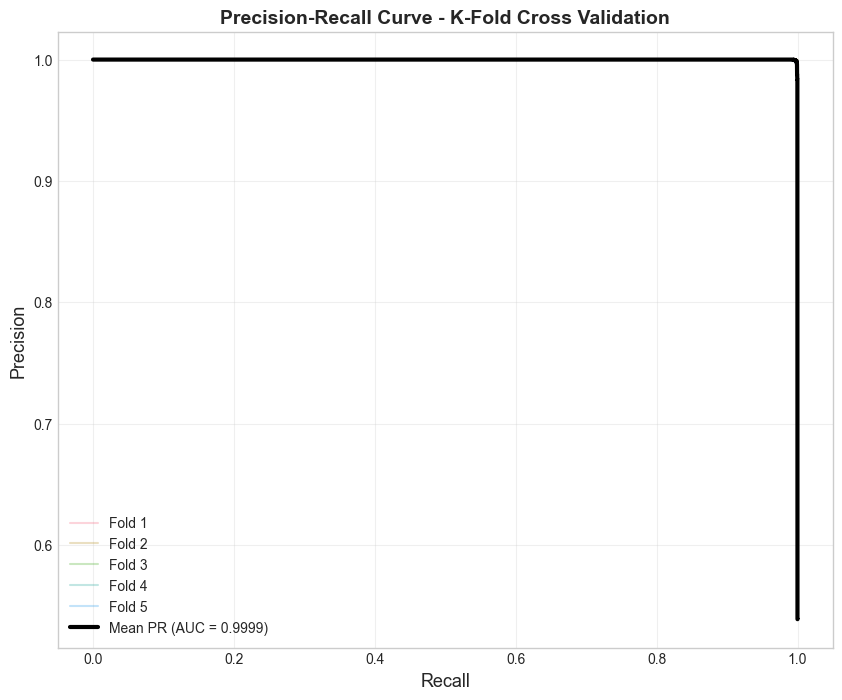

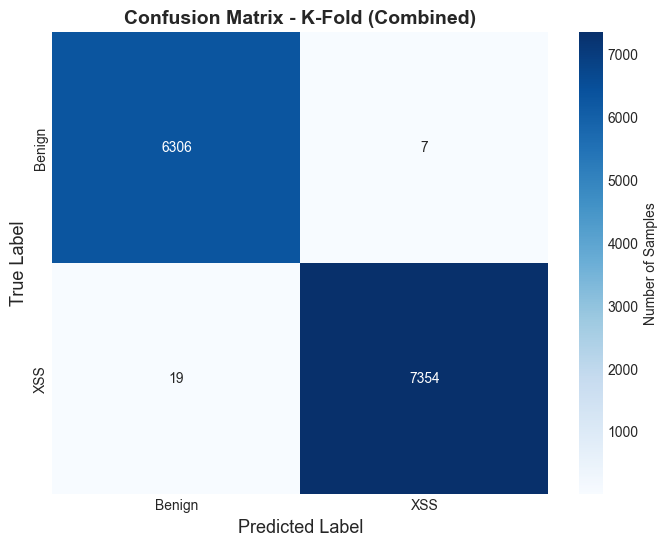

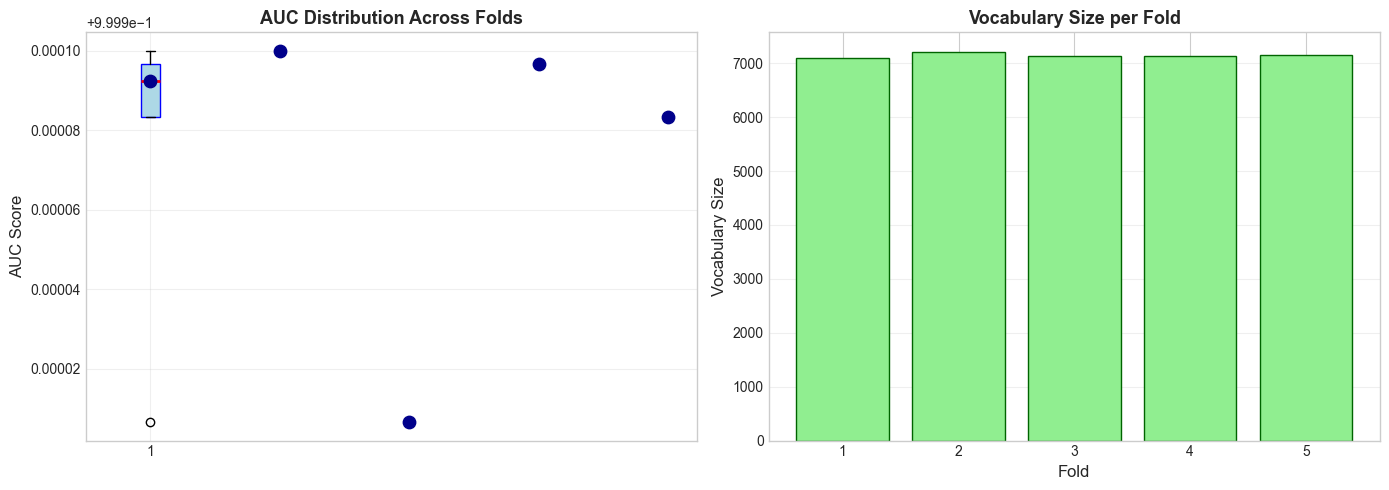


✅ تمام نمودارها در پوشه 'figures' ذخیره شدند.
📊 Mean AUC: 1.0000 ± 0.0000


In [14]:
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_palette("husl")
# fig_dir = 'figures'
# os.makedirs(fig_dir, exist_ok=True)
#
# # ------------------------------------------------
# # 1️⃣ plot Loss & AUC for any fold
# # ------------------------------------------------
# fig, axes = plt.subplots(2, N_SPLITS//2, figsize=(18, 10))
# axes = axes.flatten()
#
# for i, result in enumerate(fold_results):
#     ax1 = axes[i]
#     ax2 = ax1.twinx()
#
#     line1 = ax1.plot(result['train_losses'], 'b-', label='Train Loss', linewidth=2)
#     ax1.set_xlabel('Epoch', fontsize=11)
#     ax1.set_ylabel('Loss', color='b', fontsize=11)
#     ax1.tick_params(axis='y', labelcolor='b')
#
#     line2 = ax2.plot(result['val_aucs'], 'r-', label='Val AUC', linewidth=2)
#     ax2.set_ylabel('AUC', color='r', fontsize=11)
#     ax2.tick_params(axis='y', labelcolor='r')
#
#     ax1.set_title(f'Fold {result["fold"]} - Best AUC: {result["best_auc"]:.4f}',
#                   fontsize=12, fontweight='bold')
#
#     lines = line1 + line2
#     labels = [l.get_label() for l in lines]
#     ax1.legend(lines, labels, loc='center right')
#     ax1.grid(True, alpha=0.3)
#
# plt.tight_layout()
# plt.savefig(f'{fig_dir}/kfold_training_curves.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # ------------------------------------------------
# # 2️⃣ ROC Curve
# # ------------------------------------------------
# plt.figure(figsize=(10, 8))
#
# for i in range(N_SPLITS):
#     fpr, tpr, _ = roc_curve(all_fold_y_val[i], all_fold_probs[i])
#     plt.plot(fpr, tpr, alpha=0.3, label=f'Fold {i+1} (AUC = {auc_scores[i]:.3f})')
#
# y_val_combined = np.concatenate(all_fold_y_val)
# probs_combined = np.concatenate(all_fold_probs)
# fpr_mean, tpr_mean, _ = roc_curve(y_val_combined, probs_combined)
# auc_mean = auc(fpr_mean, tpr_mean)
#
# plt.plot(fpr_mean, tpr_mean, 'k-', linewidth=3,
#          label=f'Mean ROC (AUC = {auc_mean:.3f})')
# plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
#
# plt.xlabel('False Positive Rate', fontsize=13)
# plt.ylabel('True Positive Rate', fontsize=13)
# plt.title('ROC Curve - K-Fold Cross Validation', fontsize=14, fontweight='bold')
# plt.legend(loc='lower right', fontsize=10)
# plt.grid(True, alpha=0.3)
# plt.savefig(f'{fig_dir}/kfold_roc_curve.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # ------------------------------------------------
# # 3️⃣ Precision-Recall Curve avg
# # ------------------------------------------------
# plt.figure(figsize=(10, 8))
#
# for i in range(N_SPLITS):
#     prec, rec, _ = precision_recall_curve(all_fold_y_val[i], all_fold_probs[i])
#     plt.plot(rec, prec, alpha=0.3, label=f'Fold {i+1}')
#
# prec_mean, rec_mean, _ = precision_recall_curve(y_val_combined, probs_combined)
# pr_auc_mean = auc(rec_mean, prec_mean)
#
# plt.plot(rec_mean, prec_mean, 'k-', linewidth=3,
#          label=f'Mean PR (AUC = {pr_auc_mean:.3f})')
#
# plt.xlabel('Recall', fontsize=13)
# plt.ylabel('Precision', fontsize=13)
# plt.title('Precision-Recall Curve - K-Fold Cross Validation',
#           fontsize=14, fontweight='bold')
# plt.legend(loc='lower left', fontsize=10)
# plt.grid(True, alpha=0.3)
# plt.savefig(f'{fig_dir}/kfold_pr_curve.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # ------------------------------------------------
# # 4️⃣ Confusion Matrix avg
# # ------------------------------------------------
# y_pred_combined = (probs_combined > 0.5).astype(int)
# cm = confusion_matrix(y_val_combined, y_pred_combined)
#
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Benign', 'XSS'], yticklabels=['Benign', 'XSS'],
#             cbar_kws={'label': 'Number of Samples'})
#
# plt.xlabel('Predicted Label', fontsize=13)
# plt.ylabel('True Label', fontsize=13)
# plt.title('Confusion Matrix - K-Fold (Combined)', fontsize=14, fontweight='bold')
# plt.savefig(f'{fig_dir}/kfold_confusion_matrix.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
#
# ax1.boxplot(auc_scores, patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='blue'),
#             medianprops=dict(color='red', linewidth=2))
# ax1.scatter(np.arange(1, N_SPLITS+1), auc_scores, color='darkblue', s=80, zorder=3)
# ax1.set_ylabel('AUC Score', fontsize=12)
# ax1.set_title('AUC Distribution Across Folds', fontsize=13, fontweight='bold')
# ax1.grid(True, alpha=0.3)
#
# vocab_sizes = [r['vocab_size'] for r in fold_results]
# ax2.bar(range(1, N_SPLITS+1), vocab_sizes, color='lightgreen', edgecolor='darkgreen')
# ax2.set_ylabel('Vocabulary Size', fontsize=12)
# ax2.set_xlabel('Fold', fontsize=12)
# ax2.set_title('Vocabulary Size per Fold', fontsize=13, fontweight='bold')
# ax2.grid(True, alpha=0.3, axis='y')
#
# plt.tight_layout()
# plt.savefig(f'{fig_dir}/kfold_summary_stats.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# print(f"\n✅ plots save to dir '{fig_dir}'")
# ==================== CELL 6: Graphical Visualization (FIXED) ====================
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات نمودار
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------
# 1️⃣ نمودار Loss & AUC برای هر فولد (اصلاح‌شده)
# ------------------------------------------------
# محاسبه تعداد سطر و ستون مورد نیاز
n_cols = 3  # تعداد ستون‌ها
n_rows = (N_SPLITS + n_cols - 1) // n_cols  # تقریب به سمت بالا

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # Plot Loss
    line1 = ax1.plot(result['train_losses'], 'b-', label='Train Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss', color='b', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='b')

    # Plot AUC
    line2 = ax2.plot(result['val_aucs'], 'r-', label='Val AUC', linewidth=2)
    ax2.set_ylabel('AUC', color='r', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='r')

    # عنوان
    ax1.set_title(f'Fold {result["fold"]} - Best AUC: {result["best_auc"]:.4f}',
                  fontsize=12, fontweight='bold')

    # لیگند
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    ax1.grid(True, alpha=0.3)

# پنهان کردن subplot‌های اضافی
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 2️⃣ ROC Curve میانگین + هر فولد
# ------------------------------------------------
plt.figure(figsize=(10, 8))

for i in range(N_SPLITS):
    fpr, tpr, _ = roc_curve(all_fold_y_val[i], all_fold_probs[i])
    plt.plot(fpr, tpr, alpha=0.3, label=f'Fold {i+1} (AUC = {auc_scores[i]:.3f})')

y_val_combined = np.concatenate(all_fold_y_val)
probs_combined = np.concatenate(all_fold_probs)
fpr_mean, tpr_mean, _ = roc_curve(y_val_combined, probs_combined)
auc_mean = auc(fpr_mean, tpr_mean)

plt.plot(fpr_mean, tpr_mean, 'k-', linewidth=3,
         label=f'Mean ROC (AUC = {auc_mean:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - K-Fold Cross Validation', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig(f'{fig_dir}/kfold_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 3️⃣ Precision-Recall Curve میانگین
# ------------------------------------------------
plt.figure(figsize=(10, 8))

for i in range(N_SPLITS):
    prec, rec, _ = precision_recall_curve(all_fold_y_val[i], all_fold_probs[i])
    plt.plot(rec, prec, alpha=0.3, label=f'Fold {i+1}')

prec_mean, rec_mean, _ = precision_recall_curve(y_val_combined, probs_combined)
pr_auc_mean = auc(rec_mean, prec_mean)

plt.plot(rec_mean, prec_mean, 'k-', linewidth=3,
         label=f'Mean PR (AUC = {pr_auc_mean:.4f})')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve - K-Fold Cross Validation',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig(f'{fig_dir}/kfold_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 4️⃣ Confusion Matrix میانگین
# ------------------------------------------------
y_pred_combined = (probs_combined > 0.5).astype(int)
cm = confusion_matrix(y_val_combined, y_pred_combined)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'XSS'], yticklabels=['Benign', 'XSS'],
            cbar_kws={'label': 'Number of Samples'})

plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix - K-Fold (Combined)', fontsize=14, fontweight='bold')
plt.savefig(f'{fig_dir}/kfold_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 5️⃣ نمودار توزیع AUC و اندازه Vocab
# ------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# توزیع AUC
ax1.boxplot(auc_scores, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
ax1.scatter(np.arange(1, N_SPLITS+1), auc_scores, color='darkblue', s=80, zorder=3)
ax1.set_ylabel('AUC Score', fontsize=12)
ax1.set_title('AUC Distribution Across Folds', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# اندازه Vocab
vocab_sizes = [r['vocab_size'] for r in fold_results]
ax2.bar(range(1, N_SPLITS+1), vocab_sizes, color='lightgreen', edgecolor='darkgreen')
ax2.set_ylabel('Vocabulary Size', fontsize=12)
ax2.set_xlabel('Fold', fontsize=12)
ax2.set_title('Vocabulary Size per Fold', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_summary_stats.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ تمام نمودارها در پوشه '{fig_dir}' ذخیره شدند.")
print(f"📊 Mean AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

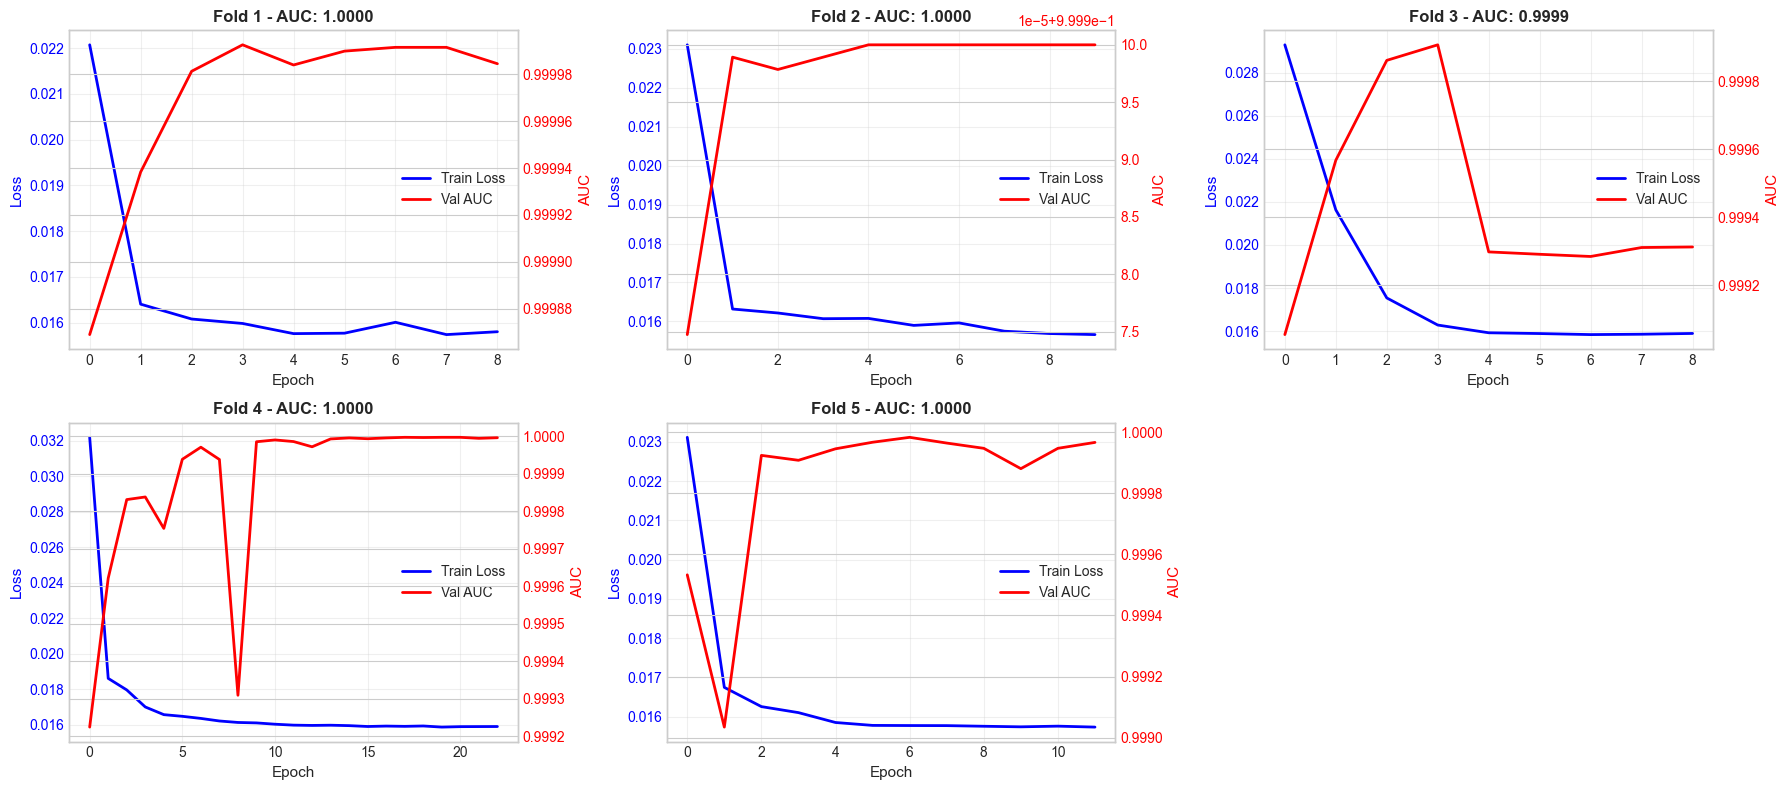

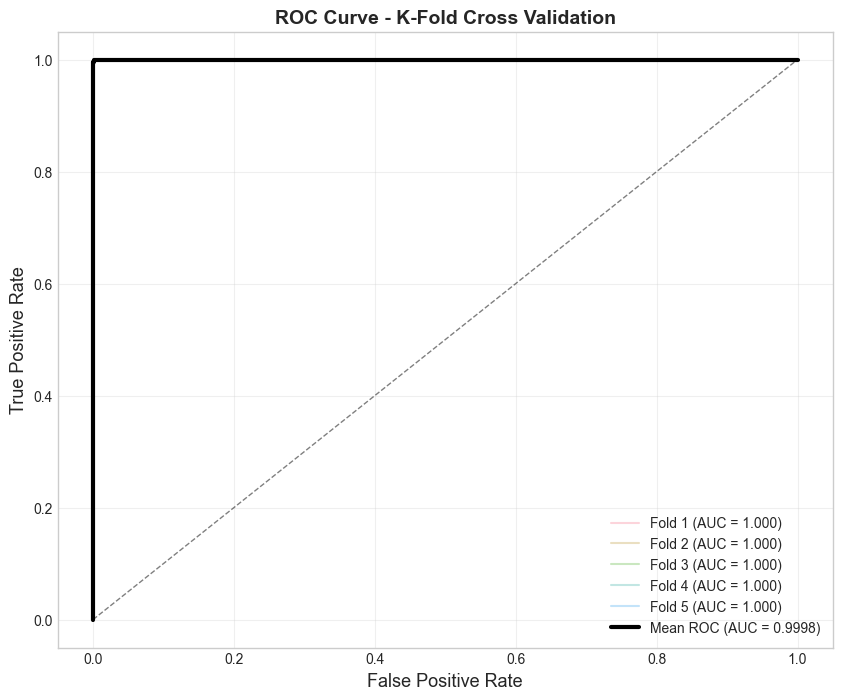

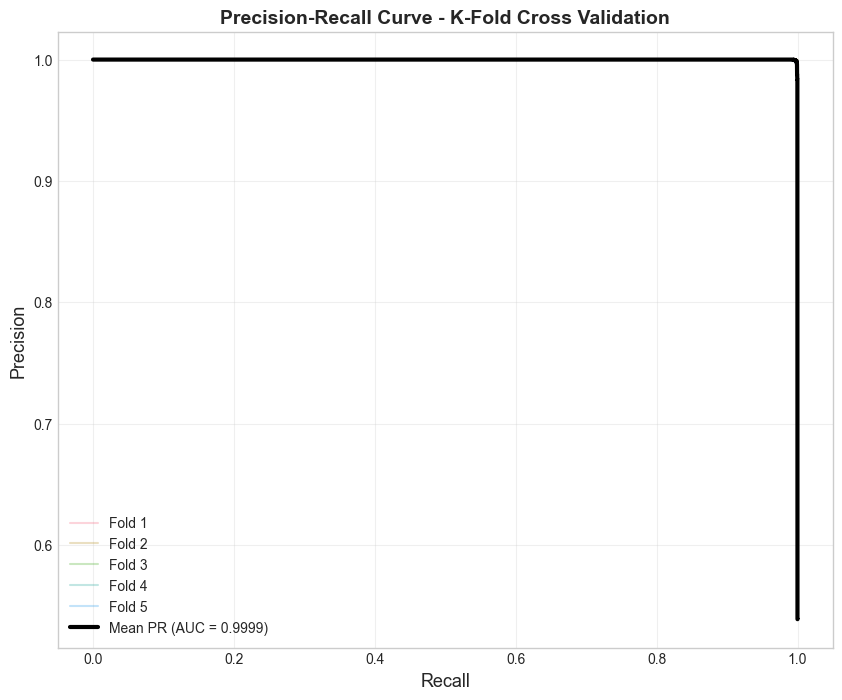

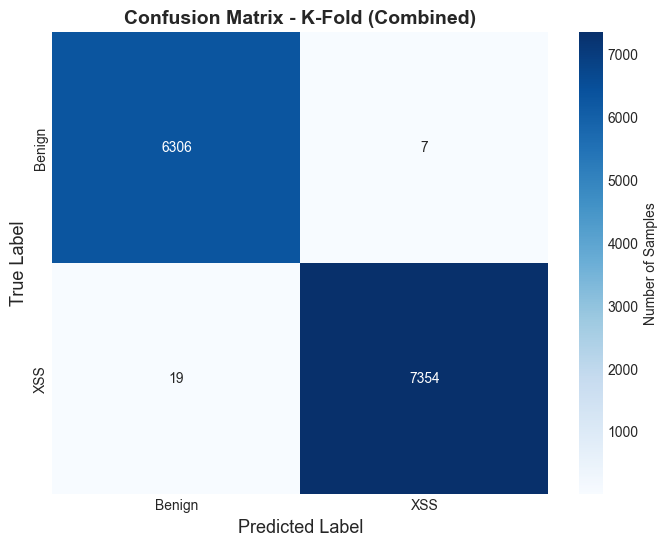

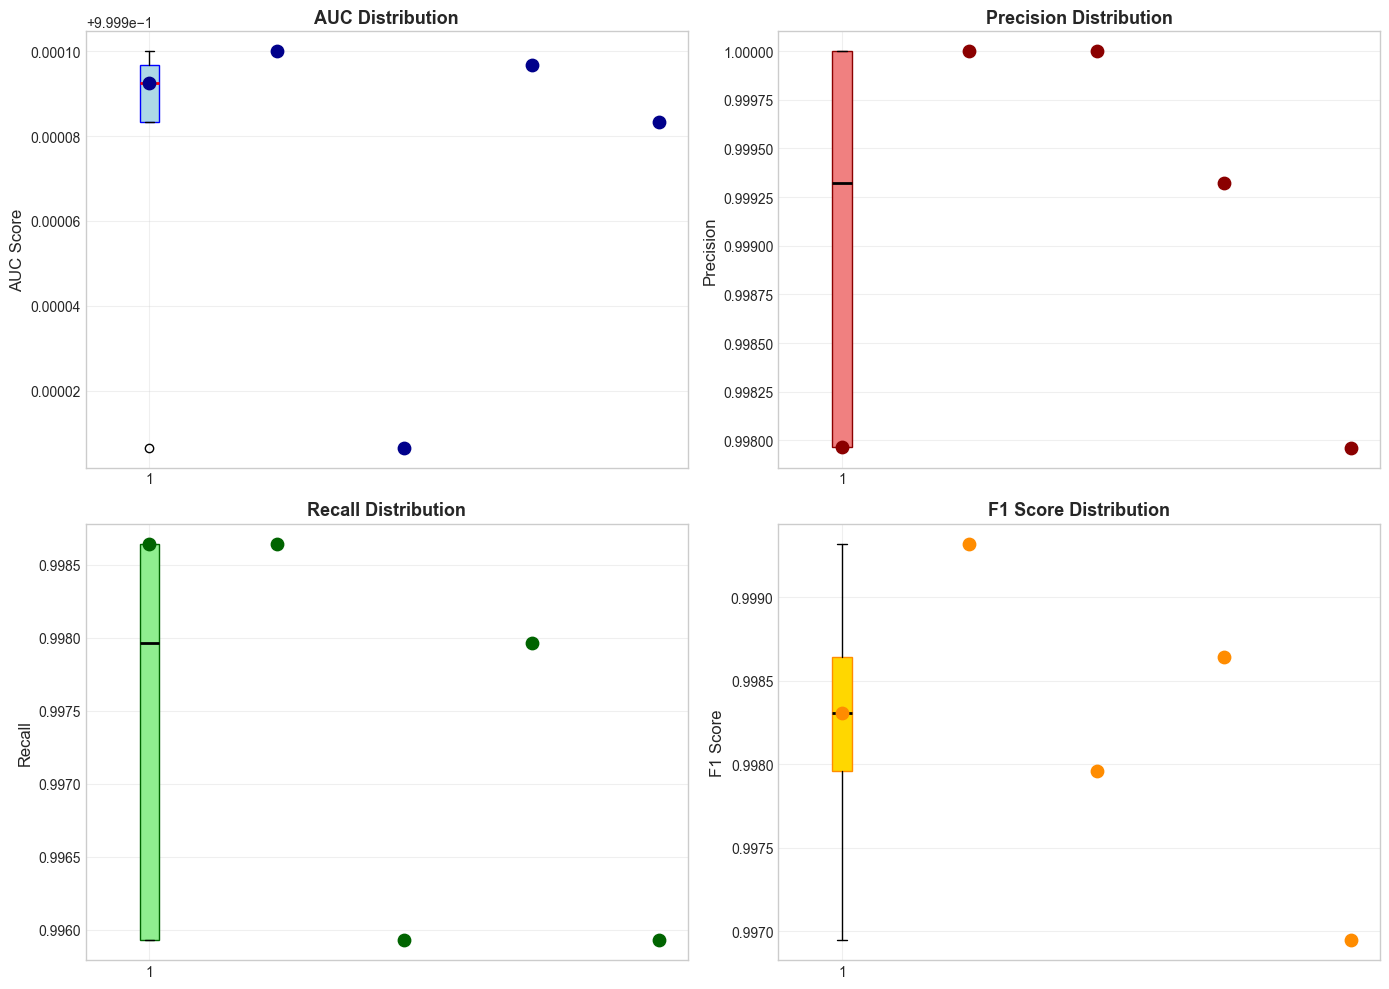

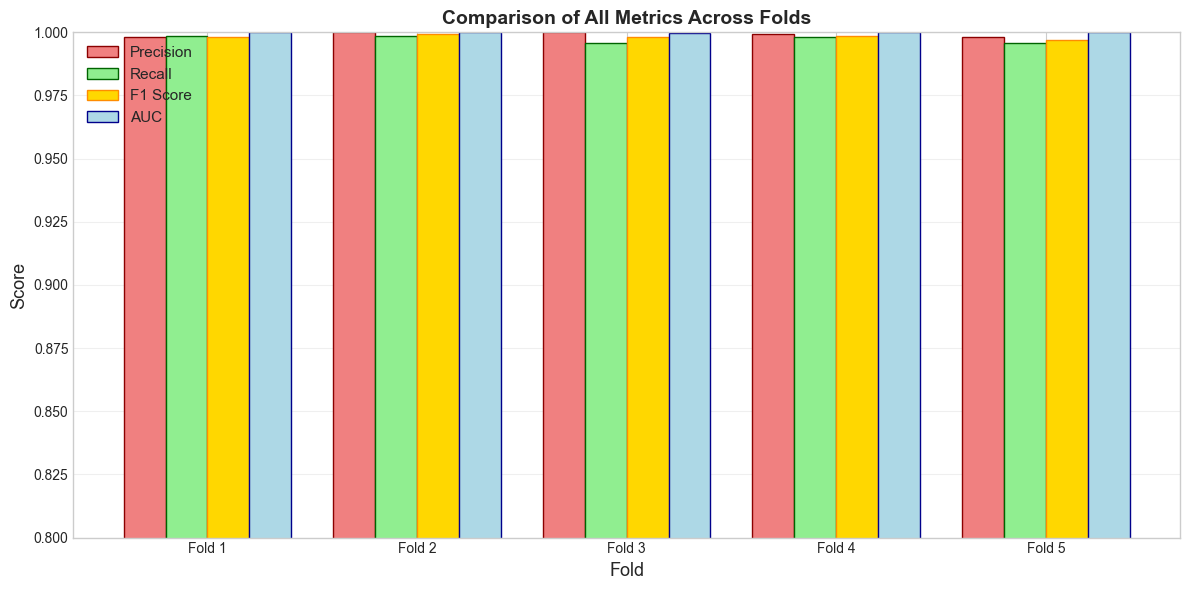

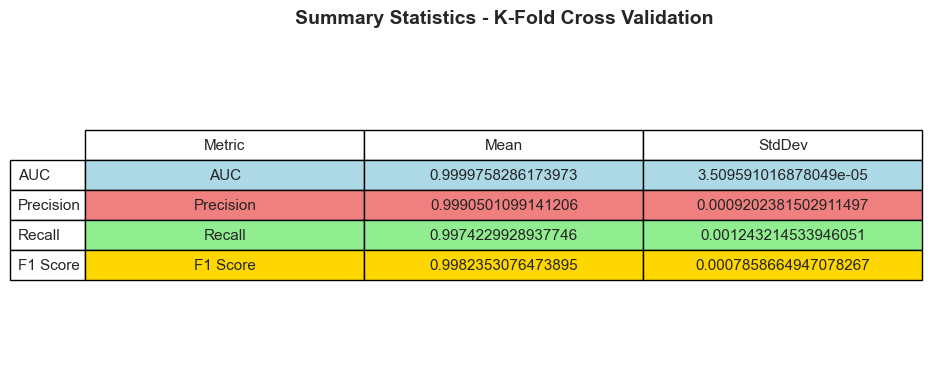


 📊 خلاصه نتایج K-Fold Cross Validation
Fold 1: Precision=0.9980 | Recall=0.9986 | F1=0.9983 | AUC=1.0000
Fold 2: Precision=1.0000 | Recall=0.9986 | F1=0.9993 | AUC=1.0000
Fold 3: Precision=1.0000 | Recall=0.9959 | F1=0.9980 | AUC=0.9999
Fold 4: Precision=0.9993 | Recall=0.9980 | F1=0.9986 | AUC=1.0000
Fold 5: Precision=0.9980 | Recall=0.9959 | F1=0.9969 | AUC=1.0000

Mean AUC:      1.0000 ± 0.0000
Mean Precision: 0.9991 ± 0.0009
Mean Recall:    0.9974 ± 0.0012
Mean F1 Score:  0.9982 ± 0.0008

✅ تمام نمودارها در پوشه 'figures' ذخیره شدند.


In [15]:
# ==================== CELL 6: Graphical Visualization (FULL METRICS) ====================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# تنظیمات نمودار
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------
# محاسبه متریک‌های اضافی برای هر فولد
# ------------------------------------------------
fold_metrics = []
for i in range(N_SPLITS):
    y_true = all_fold_y_val[i]
    y_pred = (all_fold_probs[i] > 0.5).astype(int)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    fold_metrics.append({
        'fold': i+1,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# ------------------------------------------------
# 1️⃣ نمودار Loss & AUC برای هر فولد
# ------------------------------------------------
n_cols = 3
n_rows = (N_SPLITS + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    line1 = ax1.plot(result['train_losses'], 'b-', label='Train Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss', color='b', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='b')

    line2 = ax2.plot(result['val_aucs'], 'r-', label='Val AUC', linewidth=2)
    ax2.set_ylabel('AUC', color='r', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='r')

    ax1.set_title(f'Fold {result["fold"]} - AUC: {result["best_auc"]:.4f}',
                  fontsize=12, fontweight='bold')

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')
    ax1.grid(True, alpha=0.3)

# پنهان کردن subplot‌های اضافی
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 2️⃣ ROC Curve میانگین + هر فولد
# ------------------------------------------------
plt.figure(figsize=(10, 8))

for i in range(N_SPLITS):
    fpr, tpr, _ = roc_curve(all_fold_y_val[i], all_fold_probs[i])
    plt.plot(fpr, tpr, alpha=0.3, label=f'Fold {i+1} (AUC = {auc_scores[i]:.3f})')

y_val_combined = np.concatenate(all_fold_y_val)
probs_combined = np.concatenate(all_fold_probs)
fpr_mean, tpr_mean, _ = roc_curve(y_val_combined, probs_combined)
auc_mean = auc(fpr_mean, tpr_mean)

plt.plot(fpr_mean, tpr_mean, 'k-', linewidth=3,
         label=f'Mean ROC (AUC = {auc_mean:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - K-Fold Cross Validation', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig(f'{fig_dir}/kfold_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 3️⃣ Precision-Recall Curve میانگین
# ------------------------------------------------
plt.figure(figsize=(10, 8))

for i in range(N_SPLITS):
    prec, rec, _ = precision_recall_curve(all_fold_y_val[i], all_fold_probs[i])
    plt.plot(rec, prec, alpha=0.3, label=f'Fold {i+1}')

prec_mean, rec_mean, _ = precision_recall_curve(y_val_combined, probs_combined)
pr_auc_mean = auc(rec_mean, prec_mean)

plt.plot(rec_mean, prec_mean, 'k-', linewidth=3,
         label=f'Mean PR (AUC = {pr_auc_mean:.4f})')

plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('Precision-Recall Curve - K-Fold Cross Validation',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.savefig(f'{fig_dir}/kfold_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 4️⃣ Confusion Matrix میانگین
# ------------------------------------------------
y_pred_combined = (probs_combined > 0.5).astype(int)
cm = confusion_matrix(y_val_combined, y_pred_combined)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'XSS'], yticklabels=['Benign', 'XSS'],
            cbar_kws={'label': 'Number of Samples'})

plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.title('Confusion Matrix - K-Fold (Combined)', fontsize=14, fontweight='bold')
plt.savefig(f'{fig_dir}/kfold_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 5️⃣ نمودار توزیع تمام متریک‌ها
# ------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# داده‌ها
precisions = [m['precision'] for m in fold_metrics]
recalls = [m['recall'] for m in fold_metrics]
f1_scores = [m['f1'] for m in fold_metrics]

# AUC Boxplot
axes[0].boxplot(auc_scores, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].scatter(np.arange(1, N_SPLITS+1), auc_scores, color='darkblue', s=80, zorder=3)
axes[0].set_ylabel('AUC Score', fontsize=12)
axes[0].set_title('AUC Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Precision Boxplot
axes[1].boxplot(precisions, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'),
                medianprops=dict(color='black', linewidth=2))
axes[1].scatter(np.arange(1, N_SPLITS+1), precisions, color='darkred', s=80, zorder=3)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Recall Boxplot
axes[2].boxplot(recalls, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='black', linewidth=2))
axes[2].scatter(np.arange(1, N_SPLITS+1), recalls, color='darkgreen', s=80, zorder=3)
axes[2].set_ylabel('Recall', fontsize=12)
axes[2].set_title('Recall Distribution', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# F1 Boxplot
axes[3].boxplot(f1_scores, patch_artist=True,
                boxprops=dict(facecolor='gold', color='darkorange'),
                medianprops=dict(color='black', linewidth=2))
axes[3].scatter(np.arange(1, N_SPLITS+1), f1_scores, color='darkorange', s=80, zorder=3)
axes[3].set_ylabel('F1 Score', fontsize=12)
axes[3].set_title('F1 Score Distribution', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 6️⃣ نمودار مقایسه‌ای تمام متریک‌ها در یک نمودار
# ------------------------------------------------
metrics_df = pd.DataFrame({
    'Fold': range(1, N_SPLITS+1),
    'AUC': auc_scores,
    'Precision': precisions,
    'Recall': recalls,
    'F1': f1_scores
})

plt.figure(figsize=(12, 6))
x = np.arange(N_SPLITS)
width = 0.2

plt.bar(x - 1.5*width, metrics_df['Precision'], width, label='Precision',
        color='lightcoral', edgecolor='darkred')
plt.bar(x - 0.5*width, metrics_df['Recall'], width, label='Recall',
        color='lightgreen', edgecolor='darkgreen')
plt.bar(x + 0.5*width, metrics_df['F1'], width, label='F1 Score',
        color='gold', edgecolor='darkorange')
plt.bar(x + 1.5*width, metrics_df['AUC'], width, label='AUC',
        color='lightblue', edgecolor='darkblue')

plt.xlabel('Fold', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.title('Comparison of All Metrics Across Folds', fontsize=14, fontweight='bold')
plt.xticks(x, [f'Fold {i+1}' for i in range(N_SPLITS)])
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0.8, 1.0)  # تنظیم محور y برای نمایش بهتر

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 7️⃣ جدول خلاصه نتایج (نمایش گرافیکی)
# ------------------------------------------------
summary_data = {
    'Metric': ['AUC', 'Precision', 'Recall', 'F1 Score'],
    'Mean': [np.mean(auc_scores), np.mean(precisions), np.mean(recalls), np.mean(f1_scores)],
    'StdDev': [np.std(auc_scores), np.std(precisions), np.std(recalls), np.std(f1_scores)]
}
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_df.values,
                colLabels=summary_df.columns,
                rowLabels=summary_df['Metric'],
                cellLoc='center',
                loc='center',
                colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# رنگ‌آمیزی سطرها
colors = ['lightblue', 'lightcoral', 'lightgreen', 'gold']
for i, color in enumerate(colors):
    table[(i+1, 0)].set_facecolor(color)
    table[(i+1, 1)].set_facecolor(color)
    table[(i+1, 2)].set_facecolor(color)

plt.title('Summary Statistics - K-Fold Cross Validation',
          fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{fig_dir}/kfold_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 8️⃣ نمایش مقادیر عددی در کنسول
# ------------------------------------------------
print(f"\n{'='*60}")
print(" 📊 خلاصه نتایج K-Fold Cross Validation")
print(f"{'='*60}")
for i, metric in enumerate(fold_metrics):
    print(f"Fold {i+1}: Precision={metric['precision']:.4f} | "
          f"Recall={metric['recall']:.4f} | F1={metric['f1']:.4f} | AUC={auc_scores[i]:.4f}")

print(f"\n{'='*40}")
print(f"Mean AUC:      {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Mean Precision: {np.mean(precisions):.4f} ± {np.std(precisions):.4f}")
print(f"Mean Recall:    {np.mean(recalls):.4f} ± {np.std(recalls):.4f}")
print(f"Mean F1 Score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"{'='*40}")
print(f"\n✅ تمام نمودارها در پوشه '{fig_dir}' ذخیره شدند.")

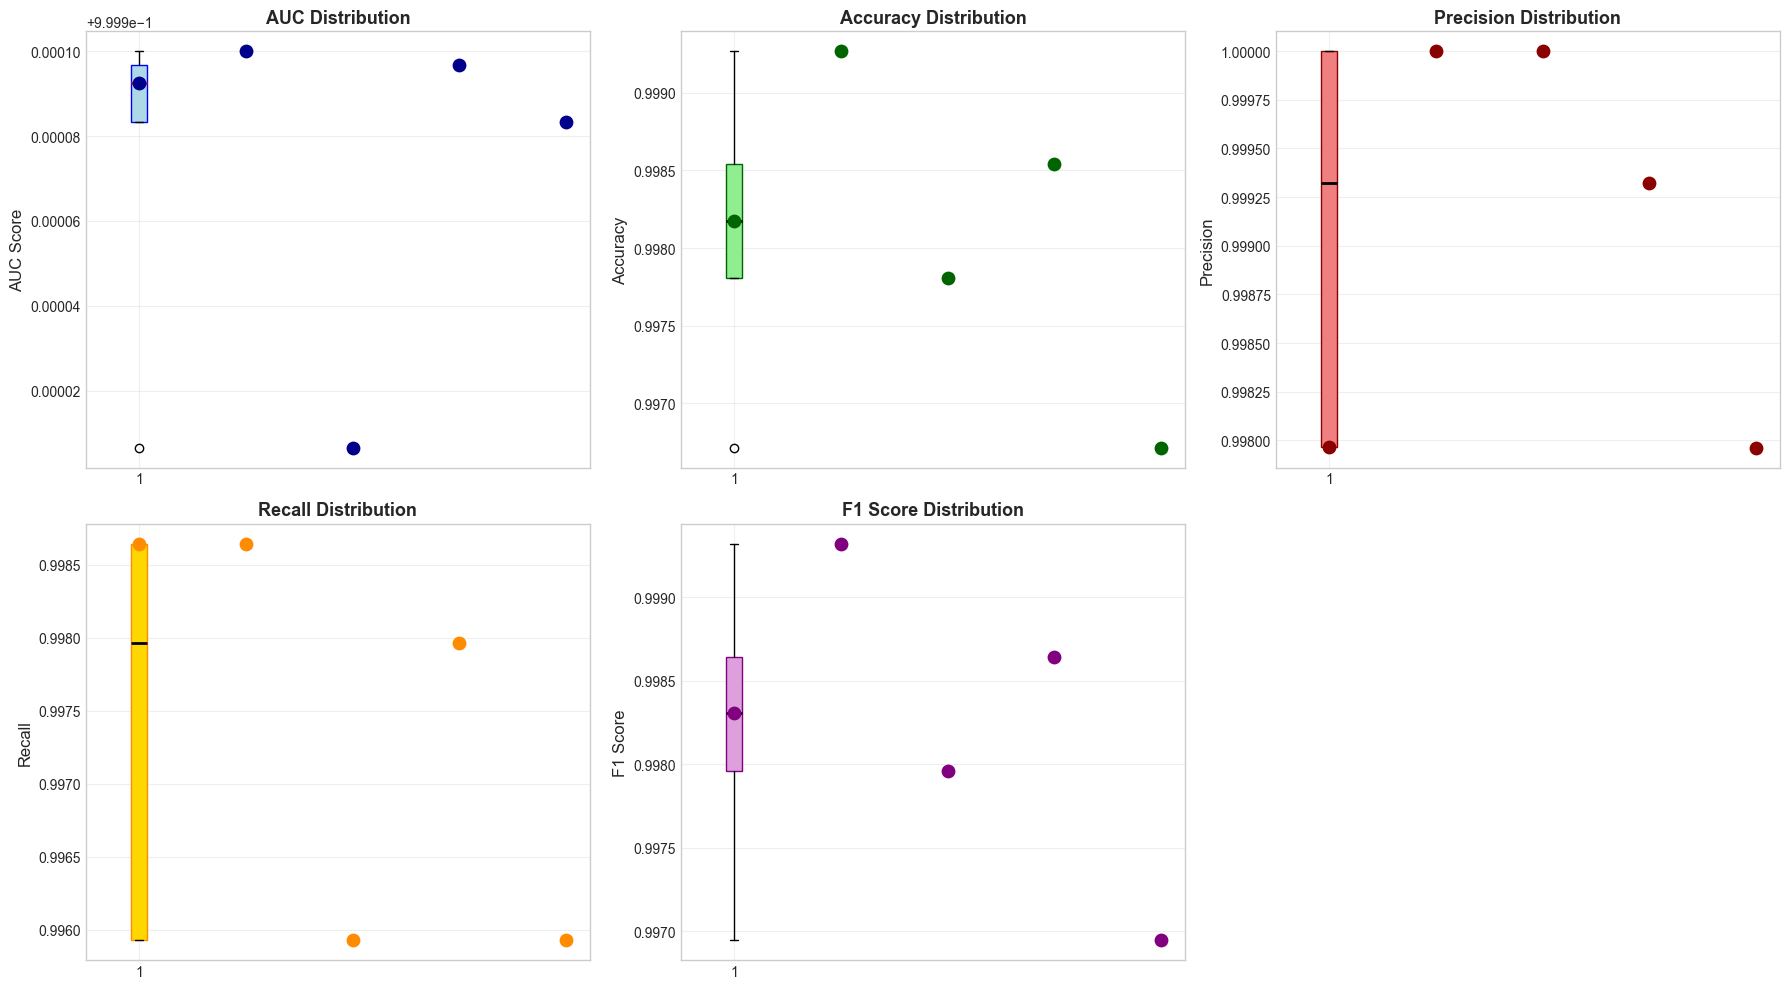

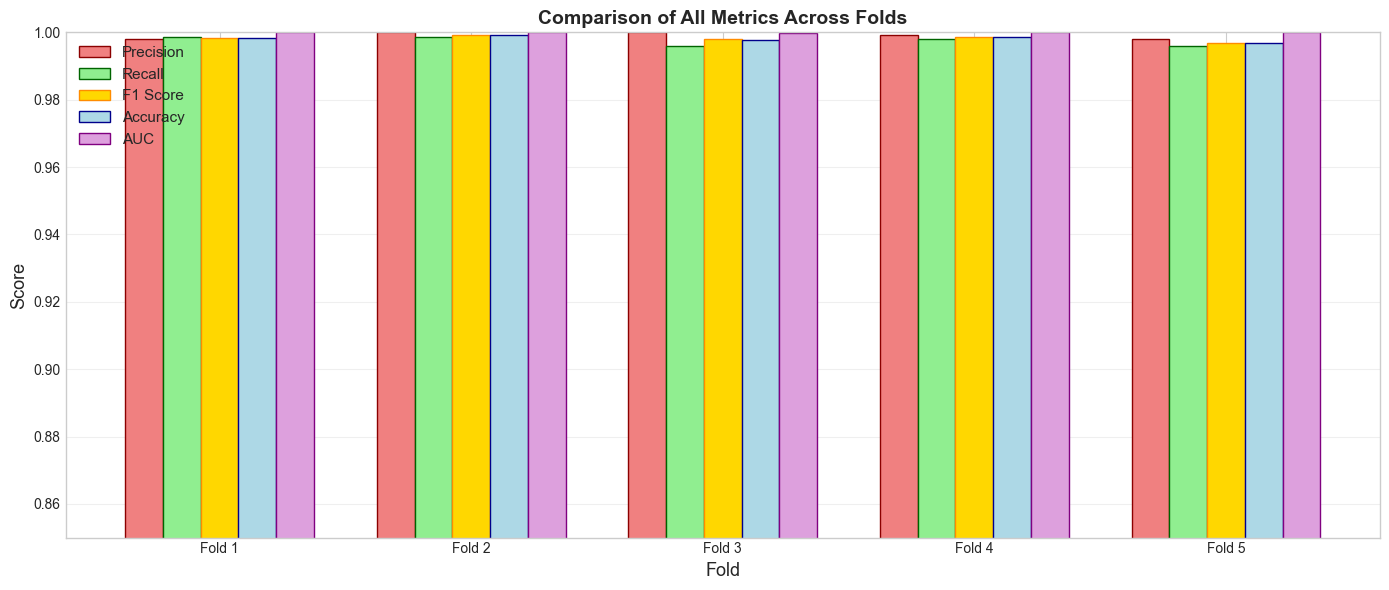

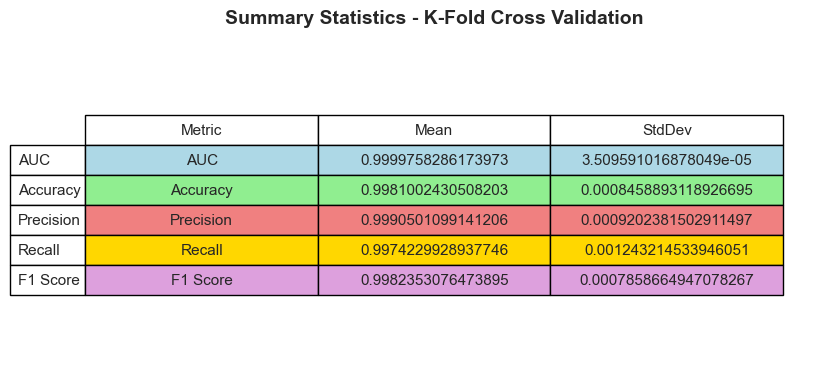


 🎯 مقادیر ACCURACY هر فولد:
   Fold 1: Accuracy = 0.9982
   Fold 2: Accuracy = 0.9993
   Fold 3: Accuracy = 0.9978
   Fold 4: Accuracy = 0.9985
   Fold 5: Accuracy = 0.9967

 📊 خلاصه تمام متریک‌ها (Mean ± StdDev):
Metric          Mean         StdDev      
----------------------------------------
Accuracy        0.9981       0.0008      
Precision       0.9991       0.0009      
Recall          0.9974       0.0012      
F1 Score        0.9982       0.0008      
AUC             1.0000       0.0000      

✅ تمام نمودارها در پوشه 'figures' ذخیره شدند.


In [16]:
# ==================== CELL 6: Graphical Visualization (with ACCURACY) ====================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# تنظیمات نمودار
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)

# ------------------------------------------------
# 🔍 محاسبه متریک‌ها برای هر فولد (شامل Accuracy)
# ------------------------------------------------
fold_metrics = []
for i in range(N_SPLITS):
    y_true = all_fold_y_val[i]
    y_pred = (all_fold_probs[i] > 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    fold_metrics.append({
        'fold': i+1,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# ------------------------------------------------
# 5️⃣ 📊 نمودار توزیع تمام متریک‌ها (2x3 Grid)
# ------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2 سطر، 3 ستون
axes = axes.flatten()

precisions = [m['precision'] for m in fold_metrics]
recalls = [m['recall'] for m in fold_metrics]
f1_scores = [m['f1'] for m in fold_metrics]
accuracies = [m['accuracy'] for m in fold_metrics]

# AUC
axes[0].boxplot(auc_scores, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].scatter(np.arange(1, N_SPLITS+1), auc_scores, color='darkblue', s=80, zorder=3)
axes[0].set_ylabel('AUC Score', fontsize=12)
axes[0].set_title('AUC Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ACCURACY
axes[1].boxplot(accuracies, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                medianprops=dict(color='black', linewidth=2))
axes[1].scatter(np.arange(1, N_SPLITS+1), accuracies, color='darkgreen', s=80, zorder=3)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# PRECISION
axes[2].boxplot(precisions, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'),
                medianprops=dict(color='black', linewidth=2))
axes[2].scatter(np.arange(1, N_SPLITS+1), precisions, color='darkred', s=80, zorder=3)
axes[2].set_ylabel('Precision', fontsize=12)
axes[2].set_title('Precision Distribution', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# RECALL
axes[3].boxplot(recalls, patch_artist=True,
                boxprops=dict(facecolor='gold', color='darkorange'),
                medianprops=dict(color='black', linewidth=2))
axes[3].scatter(np.arange(1, N_SPLITS+1), recalls, color='darkorange', s=80, zorder=3)
axes[3].set_ylabel('Recall', fontsize=12)
axes[3].set_title('Recall Distribution', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)

# F1
axes[4].boxplot(f1_scores, patch_artist=True,
                boxprops=dict(facecolor='plum', color='purple'),
                medianprops=dict(color='black', linewidth=2))
axes[4].scatter(np.arange(1, N_SPLITS+1), f1_scores, color='purple', s=80, zorder=3)
axes[4].set_ylabel('F1 Score', fontsize=12)
axes[4].set_title('F1 Score Distribution', fontsize=13, fontweight='bold')
axes[4].grid(True, alpha=0.3)

# پنهان کردن subplot اضافی (ششمی)
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_metrics_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 6️⃣ نمودار مقایسه‌ای همه متریک‌ها (شامل Accuracy)
# ------------------------------------------------
metrics_df = pd.DataFrame({
    'Fold': range(1, N_SPLITS+1),
    'AUC': auc_scores,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1': f1_scores
})

plt.figure(figsize=(14, 6))
x = np.arange(N_SPLITS)
width = 0.15  # باریک‌تر برای جاگیری 5 متریک

plt.bar(x - 2*width, metrics_df['Precision'], width, label='Precision',
        color='lightcoral', edgecolor='darkred')
plt.bar(x - width, metrics_df['Recall'], width, label='Recall',
        color='lightgreen', edgecolor='darkgreen')
plt.bar(x, metrics_df['F1'], width, label='F1 Score',
        color='gold', edgecolor='darkorange')
plt.bar(x + width, metrics_df['Accuracy'], width, label='Accuracy',
        color='lightblue', edgecolor='darkblue')
plt.bar(x + 2*width, metrics_df['AUC'], width, label='AUC',
        color='plum', edgecolor='purple')

plt.xlabel('Fold', fontsize=13)
plt.ylabel('Score', fontsize=13)
plt.title('Comparison of All Metrics Across Folds', fontsize=14, fontweight='bold')
plt.xticks(x, [f'Fold {i+1}' for i in range(N_SPLITS)])
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0.85, 1.0)

plt.tight_layout()
plt.savefig(f'{fig_dir}/kfold_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 7️⃣ جدول خلاصه نتایج (شامل Accuracy)
# ------------------------------------------------
summary_data = {
    'Metric': ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Mean': [np.mean(auc_scores), np.mean(accuracies), np.mean(precisions),
             np.mean(recalls), np.mean(f1_scores)],
    'StdDev': [np.std(auc_scores), np.std(accuracies), np.std(precisions),
               np.std(recalls), np.std(f1_scores)]
}
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=summary_df.values,
                colLabels=summary_df.columns,
                rowLabels=summary_df['Metric'],
                cellLoc='center',
                loc='center',
                colWidths=[0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold', 'plum']
for i, color in enumerate(colors):
    table[(i+1, 0)].set_facecolor(color)
    table[(i+1, 1)].set_facecolor(color)
    table[(i+1, 2)].set_facecolor(color)

plt.title('Summary Statistics - K-Fold Cross Validation',
          fontsize=14, fontweight='bold', pad=20)
plt.savefig(f'{fig_dir}/kfold_summary_table.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 8️⃣ 🎯 نمایش مقادیر Accuracy در کنسول
# ------------------------------------------------
print(f"\n{'='*70}")
print(" 🎯 مقادیر ACCURACY هر فولد:")
print(f"{'='*70}")
for i, metric in enumerate(fold_metrics):
    print(f"   Fold {metric['fold']}: Accuracy = {metric['accuracy']:.4f}")

print(f"\n{'='*70}")
print(" 📊 خلاصه تمام متریک‌ها (Mean ± StdDev):")
print(f"{'='*70}")
print(f"{'Metric':<15} {'Mean':<12} {'StdDev':<12}")
print(f"-"*40)
print(f"{'Accuracy':<15} {np.mean(accuracies):<12.4f} {np.std(accuracies):<12.4f}")
print(f"{'Precision':<15} {np.mean(precisions):<12.4f} {np.std(precisions):<12.4f}")
print(f"{'Recall':<15} {np.mean(recalls):<12.4f} {np.std(recalls):<12.4f}")
print(f"{'F1 Score':<15} {np.mean(f1_scores):<12.4f} {np.std(f1_scores):<12.4f}")
print(f"{'AUC':<15} {np.mean(auc_scores):<12.4f} {np.std(auc_scores):<12.4f}")
print(f"{'='*70}")
print(f"\n✅ تمام نمودارها در پوشه '{fig_dir}' ذخیره شدند.")

In [ ]:
test_df = pd.read_csv('data/XSS_dataset.csv')
test_texts = test_df['sentence'].astype(str).values
test_labels = test_df['Label'].astype(int).values

test_tok = [xss_tokenize(xss_preprocess(t)) for t in test_texts]
X_test = encode_with_vocab(test_tok, word2idx)
y_test = torch.LongTensor(test_labels)

model.eval()
with torch.no_grad():
    test_probs = torch.softmax(model(X_test.to(DEVICE)), dim=1)[:, 1].cpu().numpy()

y_pred = (test_probs > 0.5).astype(int)
print("\n========== Final Test Set Metrics ==========")
print(f'AUC: {roc_auc_score(test_labels, test_probs):.4f}')
print(f'Accuracy: {accuracy_score(test_labels, y_pred):.4f}')
print(confusion_matrix(test_labels, y_pred))